# Calcium Aluminosilicate Glass Simulation with Pedone PMMCS Potential
This notebook is designed to showcase the implementations of the amorphouspy package for simulating multi-component glasses with classical interatomic potentials.
It will be further extended to include more complex simulations and analyses.


## Potential and Elements
Simulations implemented so far are based on the PMMCS interatomic potential from A. Pedone et.al., JPCB (2006), https://doi.org/10.1021/jp0611018.
The PMMCS potential makes use of 2-body MORSE interactions between oxygen and cations, electrostatic interactions based on scaled partial charges (i.e., O=-1.2, Na=0.6, Mg=1.2, Al=1.8) among all ions, and a repulsive short-range term. It was originally fitted to reproduce the experimental crystal structures and elastic constants of oxides, silicates, and aluminosilicates.

The supported elements in alphabetical order are:

Ag, Al, Ba, Be, Ca, Co, Cr, Cu, Er, Fe, Fe3, Gd, Ge, K, Li, Mg, Mn, Na, Nd, Ni, O, P, Sc, Si, Sn, Sr, Ti, Zn, Zr

The cations can be classified into three categories:
- Alkali: Li, Na, K
- Alkaline Earth: Be, Mg, Ca, Sr, Ba
- Transition/Other: Fe, Zn, Al, Ti, Zr, etc.

Typical compositions the potential can handle include:
- Silicate-based systems: SiO2, Al2O3-SiO2, Na2O-SiO2, etc.
- Phosphate-based systems: P2O5 with modifiers (Ca, Mg, Zn, etc.)
- Mixed network formers: SiO2-P2O5-Al2O3 systems


## Standard Melt-Quenching Protocol and Parameters
Simulation settings employed in the following simulations do not represent production run conditions and are rather for demonstration purposes. They can be adjusted based on the specific requirements of your simulation. The simulation workflow consists of the following steps:

0. Random structure generation based on composition, number of atoms and density. For fast simulations, a small number of atoms (e.g., 200) is used.
1. NVT: heating from 300 to 5000 K with a constant heating rate (here: on the order of 1-10 K/ps)
2. NVT: equilibration of the melt at 5000 K for 100 ps (NVT ensemble)
3. NVT: cooling with down to 300 K (again with 1-10 K/ps)
4. NpT: equilibration at 300 K to relax the stress
5. NVT: extended equilibration at 300 K to extract thermodynamic and structural properties

Typical simulation parameters are applied: lammps metal units, periodic boundary conditions, timestep of 1-2 fs. Other default parameters are hidden in the underlying lammps functions, such as temperature damping of 100 time units and pressure damping of 1000 time units. If desired, Langevin thermostat and barostat can be used by setting the corresponding options.


# Import of packages

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from executorlib import SingleNodeExecutor


from amorphouspy import (
    melt_quench_simulation,
    md_simulation,
    generate_potential,
    get_ase_structure,
    get_structure_dict,
)

# Example Melt-Quenching Simulation

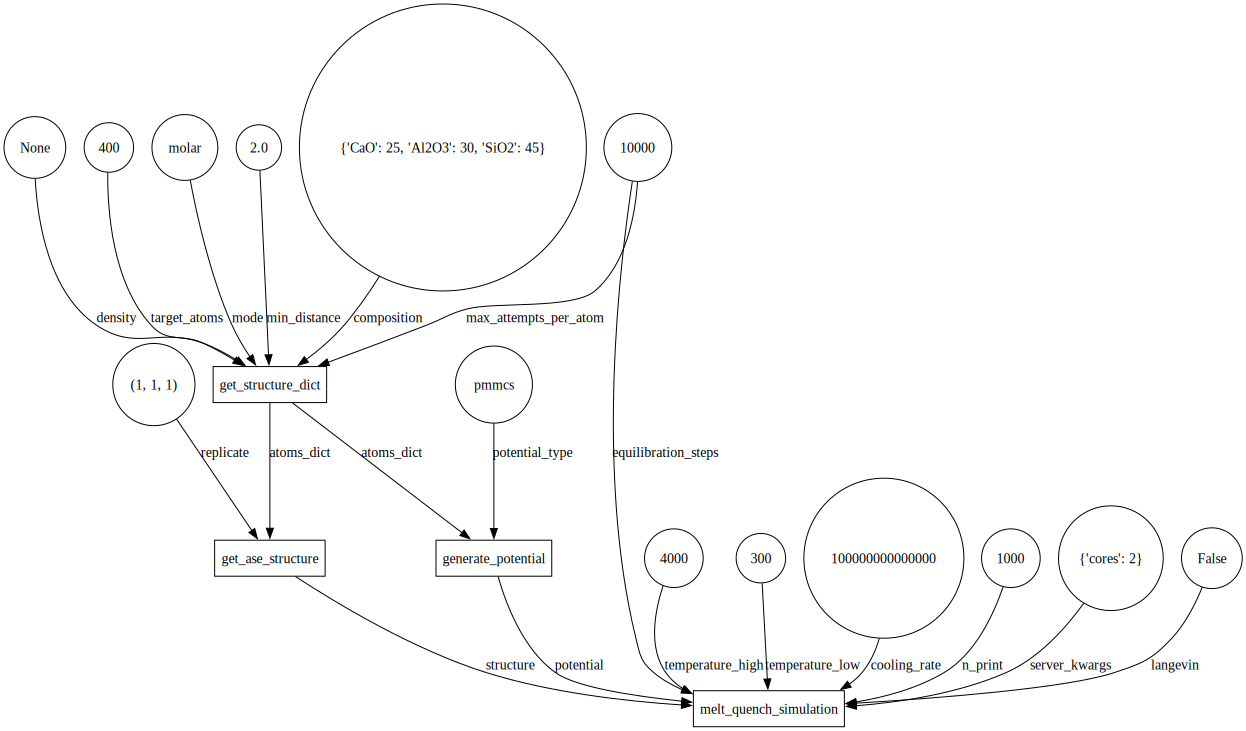

In [8]:
# Project setup,
# generating an initial random structure
# and setting up the potential information
with SingleNodeExecutor(plot_dependency_graph=True) as exe:
    atoms_dict_future = exe.submit(
        get_structure_dict,
        composition={
            "CaO": 25,
            "Al2O3": 30,
            "SiO2": 45,
        },  #    weight%: {"CaO": 20.2, "Al2O3": 36.6, "SiO2": 43.2},
        n_molecules=None,
        target_atoms=400,
        mode="molar",  # mode = "weight",
        density=None,
        min_distance=2.0,
        max_attempts_per_atom=10000,
    )
    structure_future = exe.submit(
        get_ase_structure,
        atoms_dict=atoms_dict_future,
        replicate=(1, 1, 1),
    )
    generated_potential_future = exe.submit(
        generate_potential,
        atoms_dict=atoms_dict_future,
        potential_type="pmmcs",
    )
    # Specification of the cpu parameters
    ncpus = 2
    server_kwargs = {"cores": ncpus}

    # Specification of the melt-quenching parameters
    delayed_future = exe.submit(
        melt_quench_simulation,
        structure=structure_future,
        potential=generated_potential_future,
        temperature_high=4000,
        temperature_low=300,
        n_print=1000,
        heating_rate=int(1e14),
        equilibration_steps=10000,
        cooling_rate=int(1e14),
        langevin=False,
        server_kwargs=server_kwargs,
    )
    # Run the simulation and retrieve the results. Takes 5-10 minutes with the default testing parameters.
    result = delayed_future.result()

In [9]:
# Project setup,
# generating an initial random structure
# and setting up the potential information
with SingleNodeExecutor() as exe:
    atoms_dict_future = exe.submit(
        get_structure_dict,
        composition={
            "CaO": 25,
            "Al2O3": 30,
            "SiO2": 45,
        },  #    weight%: {"CaO": 20.2, "Al2O3": 36.6, "SiO2": 43.2},
        n_molecules=None,
        target_atoms=400,
        mode="molar",  # mode = "weight",
        density=None,
        min_distance=2.0,
        max_attempts_per_atom=10000,
    )
    structure_future = exe.submit(
        get_ase_structure,
        atoms_dict=atoms_dict_future,
        replicate=(1, 1, 1),
    )
    generated_potential_future = exe.submit(
        generate_potential,
        atoms_dict=atoms_dict_future,
        potential_type="pmmcs",
    )
    # Specification of the cpu parameters
    ncpus = 2
    server_kwargs = {"cores": ncpus}

    # Specification of the melt-quenching parameters
    delayed_future = exe.submit(
        melt_quench_simulation,
        structure=structure_future,
        potential=generated_potential_future,
        temperature_high=4000,
        temperature_low=300,
        n_print=1000,
        heating_rate=int(1e15),
        equilibration_steps=10000,
        cooling_rate=int(1e15),
        langevin=False,
        server_kwargs=server_kwargs,
    )
    # Run the simulation and retrieve the results. Takes 5-10 minutes with the default testing parameters.
    result = delayed_future.result()

In [10]:
structure_glass = result["structure"]
structure_glass

Atoms(symbols='Al72Ca30O244Si53', pbc=True, cell=[[16.97956959768226, 3.1190963338051936e-15, 3.119096333805194e-15], [-2.0793975558701296e-15, 16.97956959768226, 3.1190963338051936e-15], [-2.0793975558701292e-15, -2.07939755587013e-15, 16.97956959768226]], id=..., indices=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)

304.0 K


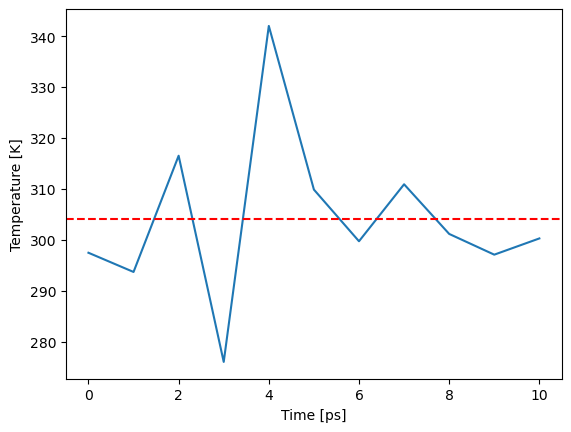

In [11]:
# Compute teh mean temperature of the last part of the simulation
mean_temp = np.mean(result["result"]["temperature"])
print(f"{mean_temp:.1f} K")

# Plot the temperature and the mean temperature
plt.plot(result["result"]["steps"] * 1e-3, result["result"]["temperature"])
plt.axhline(np.mean(result["result"]["temperature"]), color="red", linestyle="--")
plt.xlabel("Time [ps]")
plt.ylabel("Temperature [K]");

In [12]:
from ase import units

"# NBVAL_CHECK_OUTPUT"


V = np.mean(result["result"]["volume"]) * 1e-24  # volume in cm#
massTot = result["structure"].get_masses().sum() / units._Nav

density = massTot / V
print(f"{(massTot / V):.2f} g/cm3")

2.90 g/cm3


### Test single MD simulation using the output of the meltquench

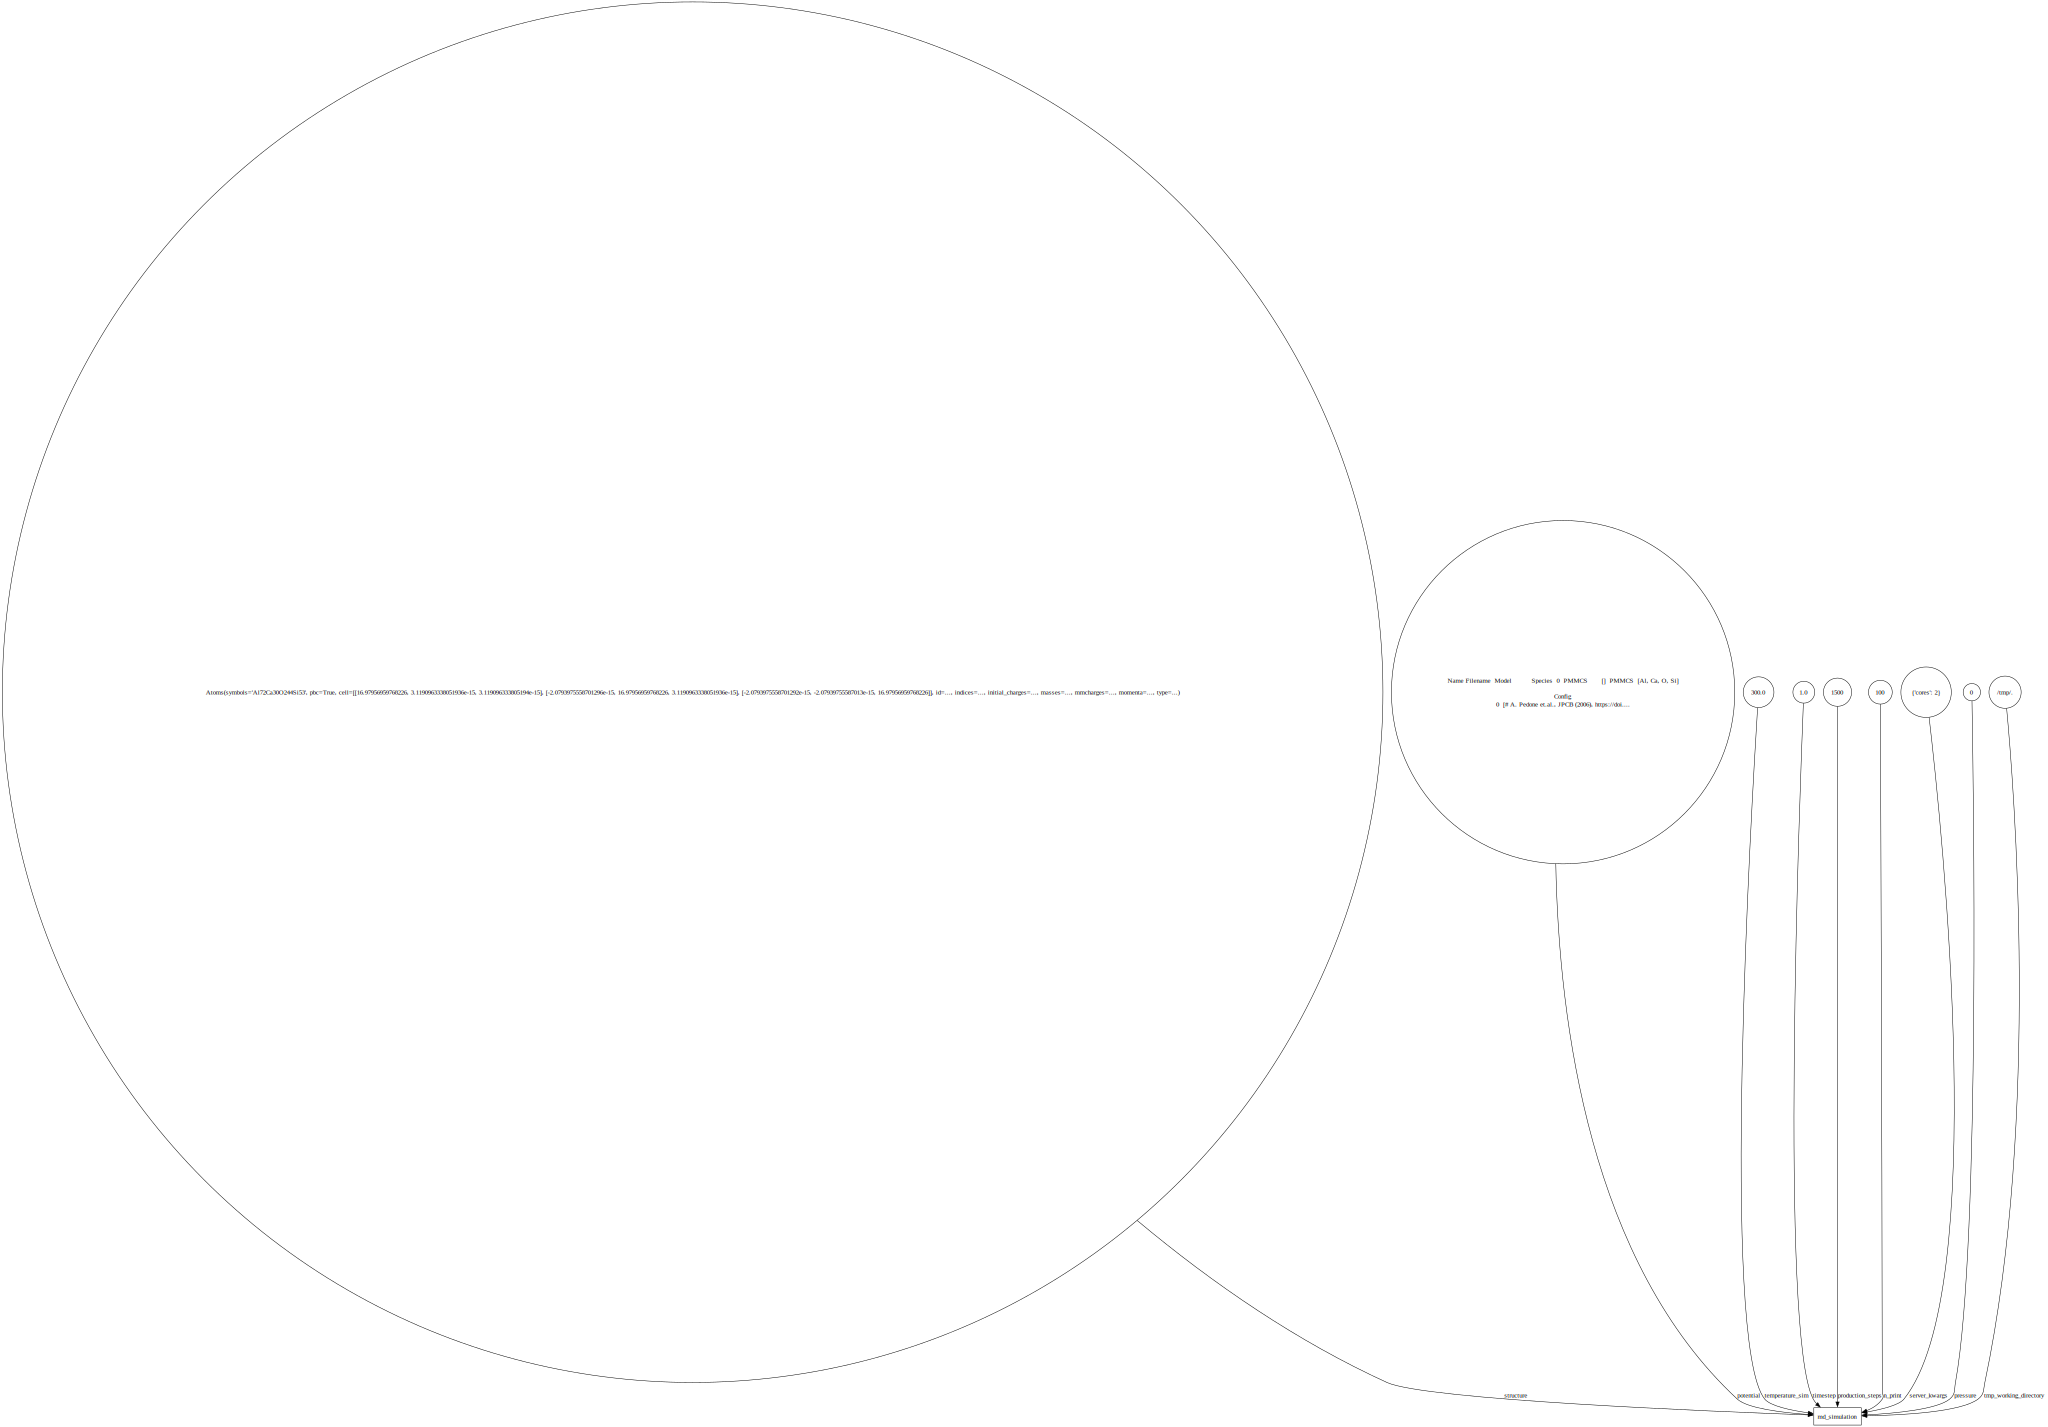

In [13]:
with SingleNodeExecutor(plot_dependency_graph=True) as exe:
    results_1 = exe.submit(
        md_simulation,
        structure=structure_glass,
        potential=generated_potential_future.result(),
        temperature_sim=300.0,
        timestep=1.0,
        production_steps=1_500,
        n_print=100,
        server_kwargs=server_kwargs,
        pressure=0,
        tmp_working_directory="/tmp/.",
    ).result()

In [14]:
with SingleNodeExecutor() as exe:
    delayed_future_1 = exe.submit(
        md_simulation,
        structure=structure_glass,
        potential=generated_potential_future.result(),
        temperature_sim=300.0,
        timestep=1.0,
        production_steps=1_500,
        n_print=100,
        server_kwargs=server_kwargs,
        pressure=0,
        tmp_working_directory="/tmp/.",
    )
    results_1 = delayed_future_1.result()

/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(


296.9 K


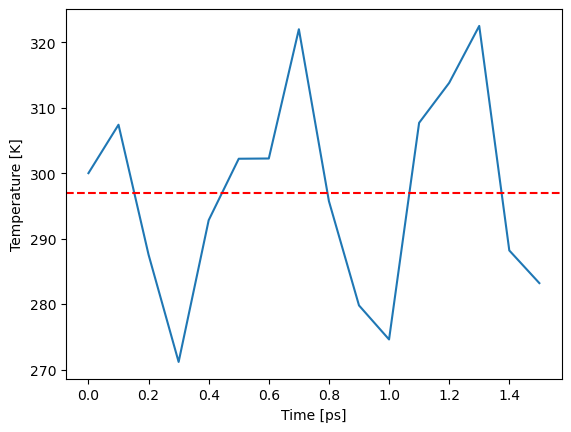

In [15]:
# Compute teh mean temperature of the last part of the simulation
mean_temp = np.mean(results_1["result"]["temperature"])
print(f"{mean_temp:.1f} K")

# Plot the temperature and the mean temperature
plt.plot(results_1["result"]["steps"] * 1e-3, results_1["result"]["temperature"])
plt.axhline(np.mean(results_1["result"]["temperature"]), color="red", linestyle="--")
plt.xlabel("Time [ps]")
plt.ylabel("Temperature [K]");

-0.0482 GPa


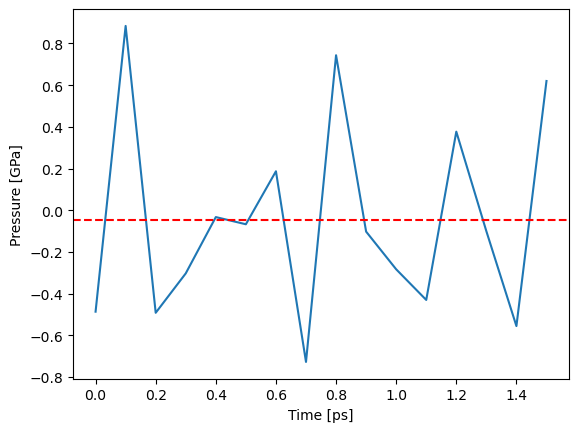

In [16]:
# Compute teh mean pressure of the last part of the simulation

pressures = results_1["result"]["pressures"]

P = (pressures[:, 0, 0] + pressures[:, 1, 1] + pressures[:, 2, 2]) / 3.0

mean_pressure = np.mean(P)
print(f"{mean_pressure:.4f} GPa")

# Plot the pressure and the mean pressure
plt.plot(results_1["result"]["steps"] * 1e-3, P)
plt.axhline(mean_pressure, color="red", linestyle="--")
plt.xlabel("Time [ps]")
plt.ylabel("Pressure [GPa]");

2.9075549835291663 g/cm3


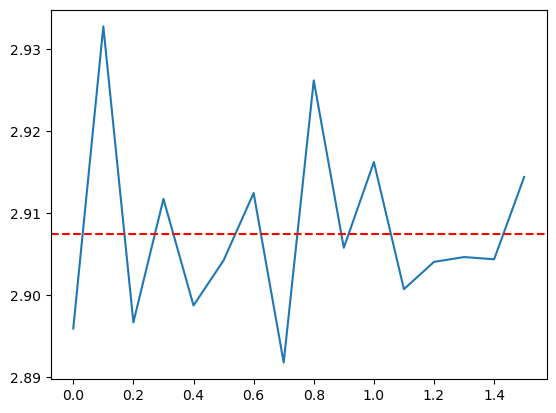

In [17]:
"# NBVAL_CHECK_OUTPUT"

V = results_1["result"]["volume"] * 1e-24  # volume in cm#
massTot = results_1["structure"].get_masses().sum() / units._Nav

density = massTot / V
print(f"{(np.mean(massTot / V))} g/cm3")

Vm = np.mean(results_1["result"]["volume"][:]) * 1e-24  # volume in cm#
densitym = massTot / Vm


plt.plot(results_1["result"]["steps"] * 1e-3, density)
plt.axhline(densitym, color="red", linestyle="--")